# Decision Tree Classification

## Assignment: Heart Disease Prediction

### Objective
To apply Decision Tree Classification to predict heart disease presence using the Cleveland Heart Disease dataset, analyze model performance, and interpret results.

### Dataset Description
908 records with 13 features including demographic, clinical, and test results:

| Feature | Description |
|---------|-------------|
| age | Age in years |
| sex | Gender (Male/Female) |
| cp | Chest pain type |
| trestbps | Resting blood pressure (mm Hg) |
| chol | Serum cholesterol (mg/dl) |
| fbs | Fasting blood sugar > 120 mg/dl |
| restecg | Resting ECG results |
| thalch | Maximum heart rate achieved |
| exang | Exercise induced angina |
| oldpeak | ST depression induced by exercise |
| slope | Slope of peak exercise ST segment |
| thal | Thalassemia |
| num | Target: 0=no disease, 1-4=stages of disease |

## 1. Import Libraries and Load Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             confusion_matrix, roc_curve, roc_auc_score, classification_report)
import warnings
warnings.filterwarnings('ignore')

plt.style.use('ggplot')
sns.set_palette('Set2')

In [2]:
df = pd.read_excel('decition tree.xlsx', sheet_name='Heart_disease')
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,thal,num
0,63,Male,typical angina,145,233,True,lv hypertrophy,150,False,2.3,downsloping,fixed defect,0
1,41,Male,atypical angina,135,203,False,normal,132,False,0.0,flat,fixed defect,0
2,57,Male,asymptomatic,140,192,False,normal,148,False,0.4,flat,fixed defect,0
3,52,Male,typical angina,118,186,False,lv hypertrophy,190,False,0.0,flat,fixed defect,0
4,57,Male,asymptomatic,110,201,False,normal,126,True,1.5,flat,fixed defect,0


In [3]:
print(f'Dataset Shape: {df.shape}')
print(f'\nData Types:\n{df.dtypes}')
print(f'\nMissing Values:\n{df.isnull().sum()}')
print(f'\nSummary Statistics:')
df.describe()

Dataset Shape: (908, 13)

Data Types:
age           int64
sex             str
cp              str
trestbps      int64
chol          int64
fbs          object
restecg         str
thalch        int64
exang        object
oldpeak     float64
slope           str
thal            str
num           int64
dtype: object

Missing Values:
age          0
sex          0
cp           0
trestbps     0
chol         0
fbs          0
restecg      0
thalch       0
exang        0
oldpeak     62
slope        0
thal         0
num          0
dtype: int64

Summary Statistics:


,age,trestbps,chol,thalch,oldpeak,num
count,908.000000,908.000000,908.000000,908.000000,846.000000,908.000000
mean,53.791850,133.430617,201.484581,135.957048,0.891253,1.008811
std,9.158031,20.401608,112.097949,26.804929,1.093875,1.144436
min,29.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.750000,120.000000,176.750000,118.000000,0.000000,0.000000
50%,54.000000,130.000000,224.000000,138.000000,0.500000,1.000000
75%,60.000000,144.000000,270.000000,156.000000,1.500000,2.000000
max,77.000000,200.000000,603.000000,202.000000,6.200000,4.000000


## 2. Exploratory Data Analysis (EDA)

### 2.1 Target Distribution

=== TARGET DISTRIBUTION (num) ===
num
0    399
1    265
2    109
3    107
4     28
Name: count, dtype: int64


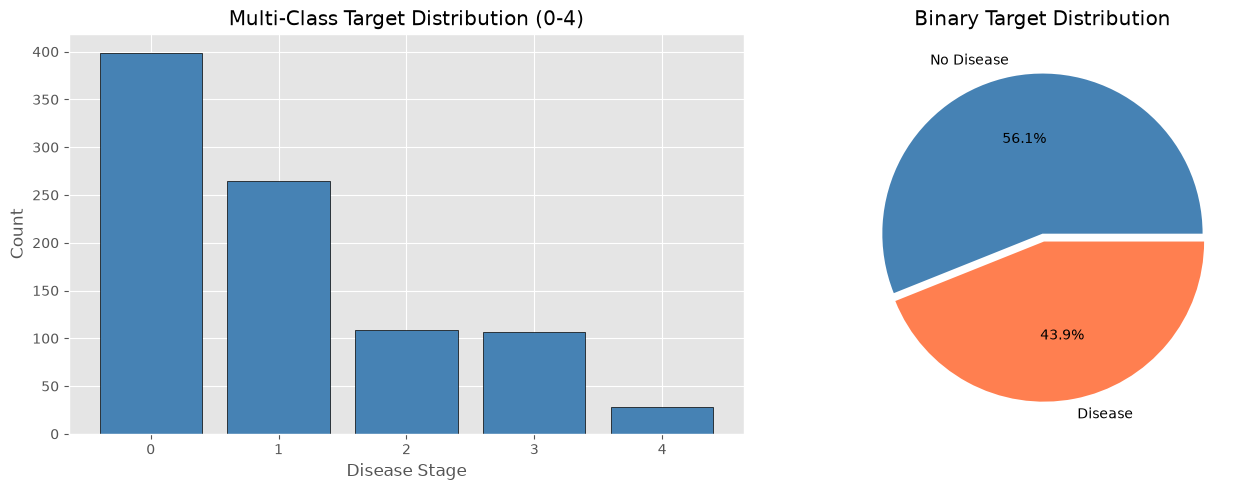

In [4]:
print('=== TARGET DISTRIBUTION (num) ===')
print(df['num'].value_counts().sort_index())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

target_counts = df['num'].value_counts().sort_index()
axes[0].bar(target_counts.index, target_counts.values, color='steelblue', edgecolor='black')
axes[0].set_title('Multi-Class Target Distribution (0-4)')
axes[0].set_xlabel('Disease Stage')
axes[0].set_ylabel('Count')

binary_target = (df['num'] > 0).astype(int)
binary_counts = binary_target.value_counts()
axes[1].pie(binary_counts.values, labels=['No Disease', 'Disease'], autopct='%1.1f%%',
            colors=['steelblue', 'coral'], explode=(0, 0.05))
axes[1].set_title('Binary Target Distribution')

plt.tight_layout()
plt.show()

### 2.2 Histograms of Numerical Features

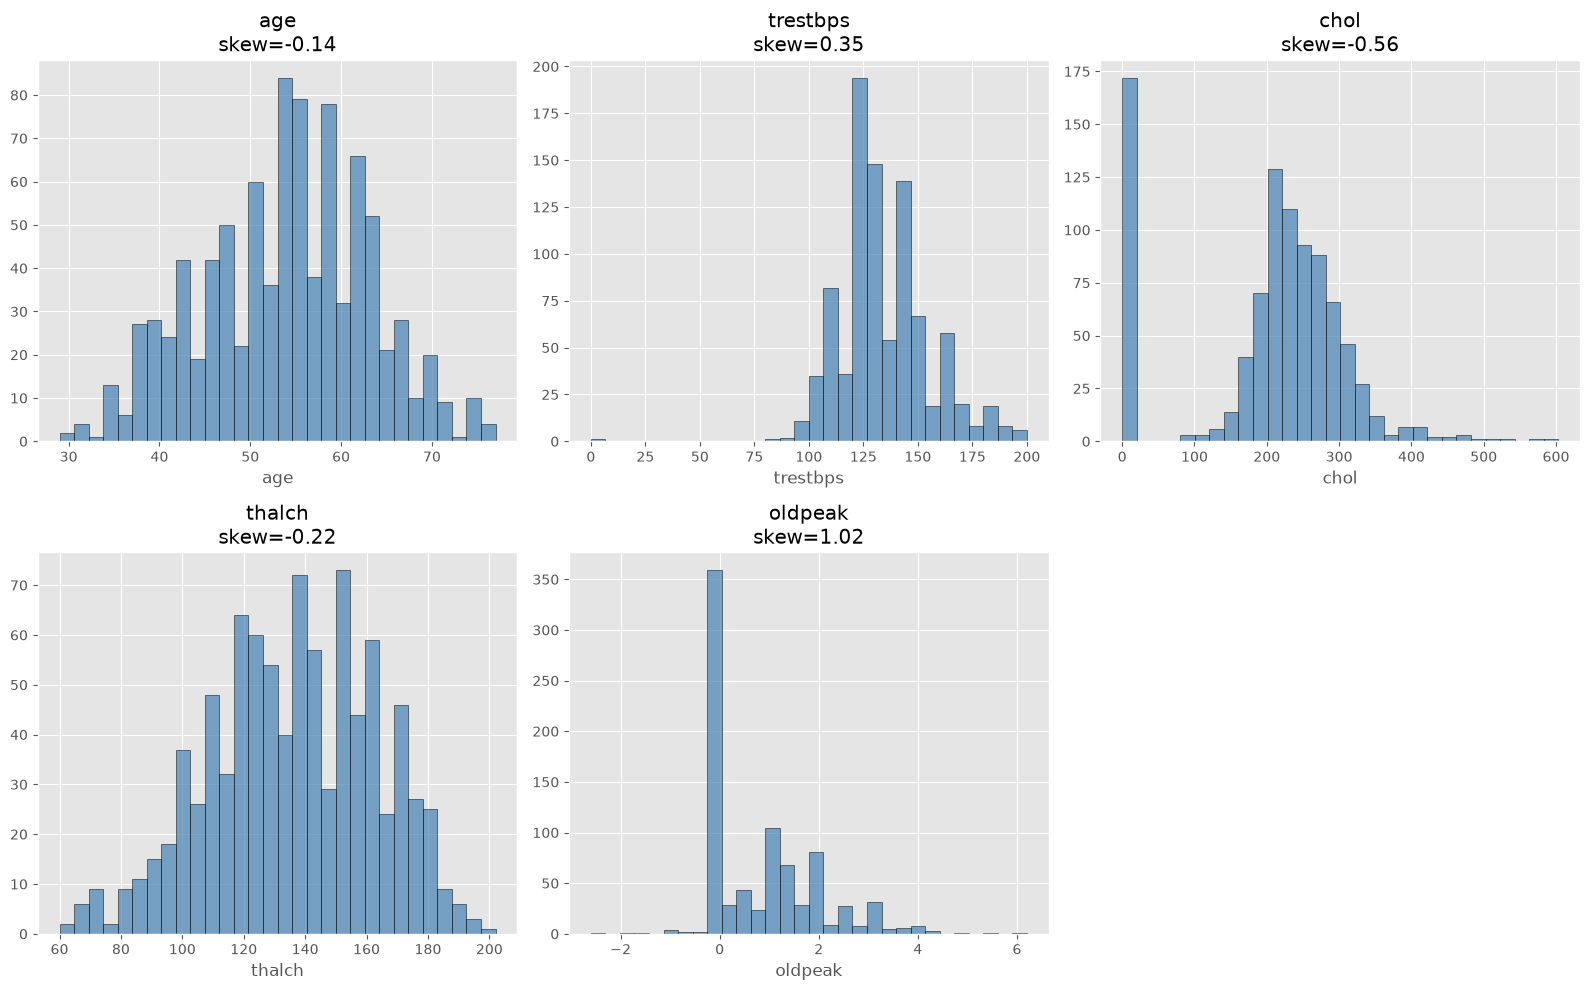

In [5]:
num_cols = ['age', 'trestbps', 'chol', 'thalch', 'oldpeak']
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    df_clean_temp = df[col].dropna()
    axes[i].hist(df_clean_temp, bins=30, edgecolor='black', color='steelblue', alpha=0.7)
    axes[i].set_title(f'{col}\nskew={df_clean_temp.skew():.2f}')
    axes[i].set_xlabel(col)

axes[5].axis('off')
plt.tight_layout()
plt.show()

### 2.3 Boxplots by Disease Status

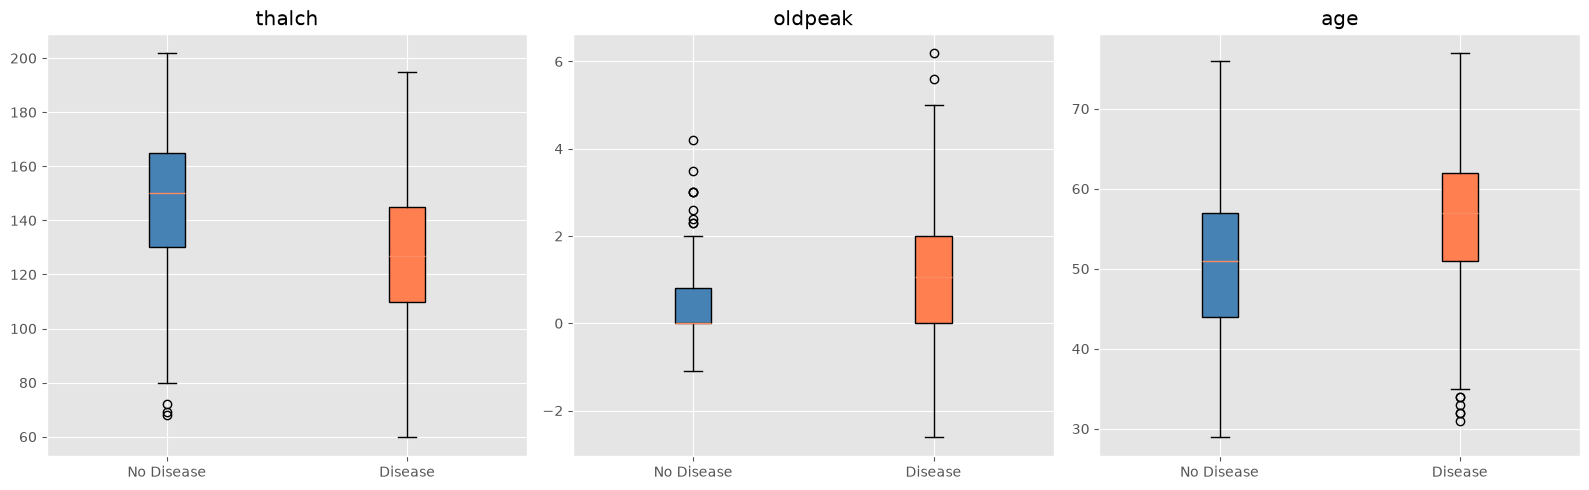

In [6]:
df_temp = df.copy()
df_temp['disease'] = (df_temp['num'] > 0).astype(int)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for i, col in enumerate(['thalch', 'oldpeak', 'age']):
    df_plot = df_temp[['disease', col]].dropna()
    bp = axes[i].boxplot([df_plot[df_plot['disease']==0][col], df_plot[df_plot['disease']==1][col]],
                         patch_artist=True)
    axes[i].set_xticklabels(['No Disease', 'Disease'])
    for patch, color in zip(bp['boxes'], ['steelblue', 'coral']):
        patch.set_facecolor(color)
    axes[i].set_title(col)

plt.tight_layout()
plt.show()

### 2.4 Correlation Heatmap

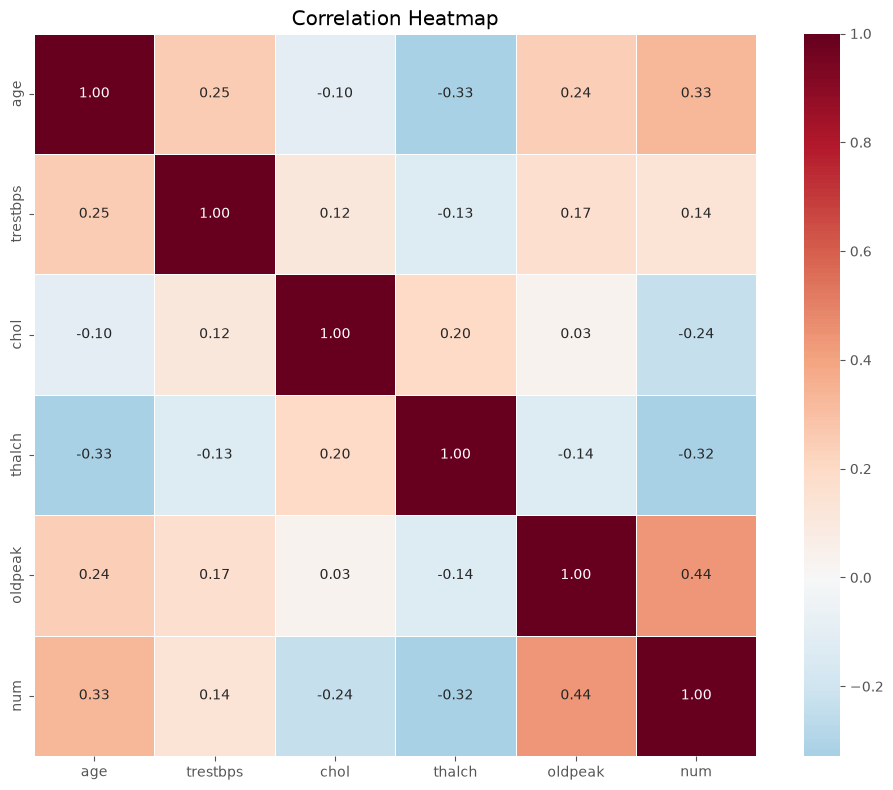

In [7]:
plt.figure(figsize=(10, 8))
corr_cols = ['age', 'trestbps', 'chol', 'thalch', 'oldpeak', 'num']
corr = df[corr_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0, linewidths=0.5, square=True)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

### EDA Insights
- **56% have heart disease** (vs 44% healthy) — balanced target
- **thalch** (max heart rate) is lower in diseased patients
- **oldpeak** (ST depression) is higher in diseased patients 
- 62 missing values in `oldpeak` need handling
- Sex imbalance: 79% Male, 21% Female

## 3. Data Preprocessing

In [8]:
df_clean = df.copy()

# Fix inconsistent boolean columns - mixed bool/str types
# Convert all to string first, then upper strip, then map
df_clean['fbs'] = df_clean['fbs'].astype(str).str.upper().str.strip()
df_clean['exang'] = df_clean['exang'].astype(str).str.upper().str.strip()

bool_map = {'TRUE': 1, 'FALSE': 0, 'TURE': 1}
df_clean['fbs'] = df_clean['fbs'].replace(bool_map).astype(int)
df_clean['exang'] = df_clean['exang'].replace(bool_map).astype(int)

print('Fixed boolean encoding inconsistencies.')
print(f"fbs unique: {df_clean['fbs'].unique()}")
print(f"exang unique: {df_clean['exang'].unique()}")

Fixed boolean encoding inconsistencies.
fbs unique: [1 0]
exang unique: [0 1]


In [9]:
# Handle missing oldpeak - impute with median
missing_oldpeak = df_clean['oldpeak'].isnull().sum()
median_oldpeak = df_clean['oldpeak'].median()
df_clean['oldpeak'] = df_clean['oldpeak'].fillna(median_oldpeak)
print(f'Imputed {missing_oldpeak} missing oldpeak values with median = {median_oldpeak:.2f}')

# Create binary target
binary_target_col = 'disease'
df_clean[binary_target_col] = (df_clean['num'] > 0).astype(int)
print(f'\nBinary target created: {binary_target_col}')
print(df_clean[binary_target_col].value_counts())
print(f'\nMissing values after preprocessing:')
print(df_clean.isnull().sum())

Imputed 62 missing oldpeak values with median = 0.50

Binary target created: disease
disease
1    509
0    399
Name: count, dtype: int64

Missing values after preprocessing:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalch      0
exang       0
oldpeak     0
slope       0
thal        0
num         0
disease     0
dtype: int64


In [10]:
# Encode categorical variables
cat_cols = ['sex', 'cp', 'restecg', 'slope', 'thal']
label_encoders = {}

for col in cat_cols:
    le = LabelEncoder()
    df_clean[col] = le.fit_transform(df_clean[col])
    label_encoders[col] = le
    print(f'{col}: {dict(zip(le.classes_, le.transform(le.classes_)))}')

sex: {'Female': 0, 'Male': 1}
cp: {'asymptomatic': 0, 'atypical angina': 1, 'non-anginal': 2, 'typical angina': 3}
restecg: {'lv hypertrophy': 0, 'normal': 1, 'st-t abnormality': 2}
slope: {'downsloping': 0, 'flat': 1, 'upsloping': 2}
thal: {'fixed defect': 0, 'normal': 1, 'reversable defect': 2}


In [11]:
# Define features and target
feature_cols = ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalch', 'exang', 'oldpeak', 'slope', 'thal']
X = df_clean[feature_cols]
y = df_clean[binary_target_col]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f'Train: {X_train.shape[0]}, Test: {X_test.shape[0]}')
print(f'Train target:\n{y_train.value_counts()}')
print(f'Test target:\n{y_test.value_counts()}')

Train: 726, Test: 182
Train target:
disease
1    407
0    319
Name: count, dtype: int64
Test target:
disease
1    102
0     80
Name: count, dtype: int64


## 4. Decision Tree Classification

In [12]:
dt_default = DecisionTreeClassifier(random_state=42)
dt_default.fit(X_train_scaled, y_train)

y_pred = dt_default.predict(X_test_scaled)
y_pred_proba = dt_default.predict_proba(X_test_scaled)[:, 1]

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)

print('=== DEFAULT DECISION TREE ===')
print(f'Accuracy:  {accuracy:.4f}')
print(f'Precision: {precision:.4f}')
print(f'Recall:    {recall:.4f}')
print(f'F1-Score:  {f1:.4f}')
print(f'ROC-AUC:   {roc_auc:.4f}')
print(f'\nDepth: {dt_default.get_depth()}')
print(f'Leaves: {dt_default.get_n_leaves()}')

=== DEFAULT DECISION TREE ===
Accuracy:  0.7033
Precision: 0.7400
Recall:    0.7255
F1-Score:  0.7327
ROC-AUC:   0.7002

Depth: 13
Leaves: 139


In [13]:
print('=== CLASSIFICATION REPORT ===')
print(classification_report(y_test, y_pred, target_names=['No Disease', 'Disease']))

=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

  No Disease       0.66      0.68      0.67        80
     Disease       0.74      0.73      0.73       102

    accuracy                           0.70       182
   macro avg       0.70      0.70      0.70       182
weighted avg       0.70      0.70      0.70       182



### 4.1 Confusion Matrix

TN: 54, FP: 26, FN: 28, TP: 74


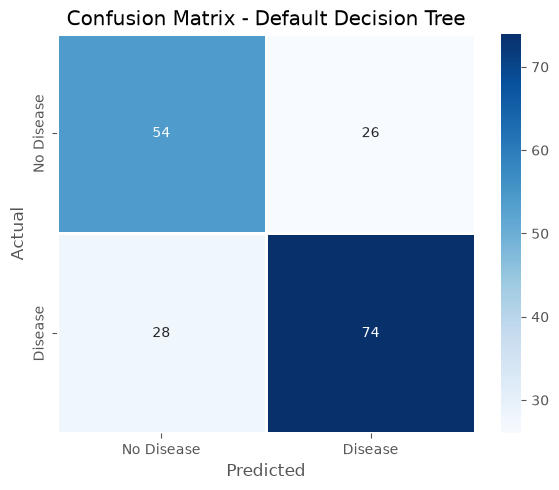

In [14]:
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No Disease', 'Disease'],
            yticklabels=['No Disease', 'Disease'], linewidths=1)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Default Decision Tree')

tn, fp, fn, tp = cm.ravel()
print(f'TN: {tn}, FP: {fp}, FN: {fn}, TP: {tp}')
plt.tight_layout()
plt.show()

## 5. Hyperparameter Tuning

In [15]:
param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 5, 10],
    'max_features': ['sqrt', 'log2', None]
}

dt = DecisionTreeClassifier(random_state=42)
grid_search = GridSearchCV(dt, param_grid, cv=5, scoring='f1', n_jobs=-1)
grid_search.fit(X_train_scaled, y_train)

print(f'Best Parameters: {grid_search.best_params_}')
print(f'Best CV Score: {grid_search.best_score_:.4f}')

Best Parameters: {'criterion': 'gini', 'max_depth': 5, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 10}
Best CV Score: 0.8054


In [16]:
dt_best = grid_search.best_estimator_
y_pred_best = dt_best.predict(X_test_scaled)
y_pred_proba_best = dt_best.predict_proba(X_test_scaled)[:, 1]

acc_best = accuracy_score(y_test, y_pred_best)
prec_best = precision_score(y_test, y_pred_best)
rec_best = recall_score(y_test, y_pred_best)
f1_best = f1_score(y_test, y_pred_best)
auc_best = roc_auc_score(y_test, y_pred_proba_best)

print('=== TUNED DECISION TREE ===')
print(f'Accuracy:  {acc_best:.4f}')
print(f'Precision: {prec_best:.4f}')
print(f'Recall:    {rec_best:.4f}')
print(f'F1-Score:  {f1_best:.4f}')
print(f'ROC-AUC:   {auc_best:.4f}')
print(f'\nDepth: {dt_best.get_depth()}')
print(f'Leaves: {dt_best.get_n_leaves()}')

=== TUNED DECISION TREE ===
Accuracy:  0.7363
Precision: 0.7700
Recall:    0.7549
F1-Score:  0.7624
ROC-AUC:   0.7672

Depth: 5
Leaves: 23


In [17]:
print('=== COMPARISON: DEFAULT vs TUNED ===')
comparison = pd.DataFrame({
    'Model': ['Default DT', 'Tuned DT'],
    'Accuracy': [accuracy, acc_best],
    'Precision': [precision, prec_best],
    'Recall': [recall, rec_best],
    'F1-Score': [f1, f1_best],
    'ROC-AUC': [roc_auc, auc_best],
    'Depth': [dt_default.get_depth(), dt_best.get_depth()],
    'Leaves': [dt_default.get_n_leaves(), dt_best.get_n_leaves()]
})
print(comparison.to_string(index=False))

=== COMPARISON: DEFAULT vs TUNED ===
     Model  Accuracy  Precision   Recall  F1-Score  ROC-AUC  Depth  Leaves
Default DT  0.703297       0.74 0.725490  0.732673 0.700245     13     139
  Tuned DT  0.736264       0.77 0.754902  0.762376 0.767157      5      23


### 5.1 Decision Tree Visualization (Tuned Model)

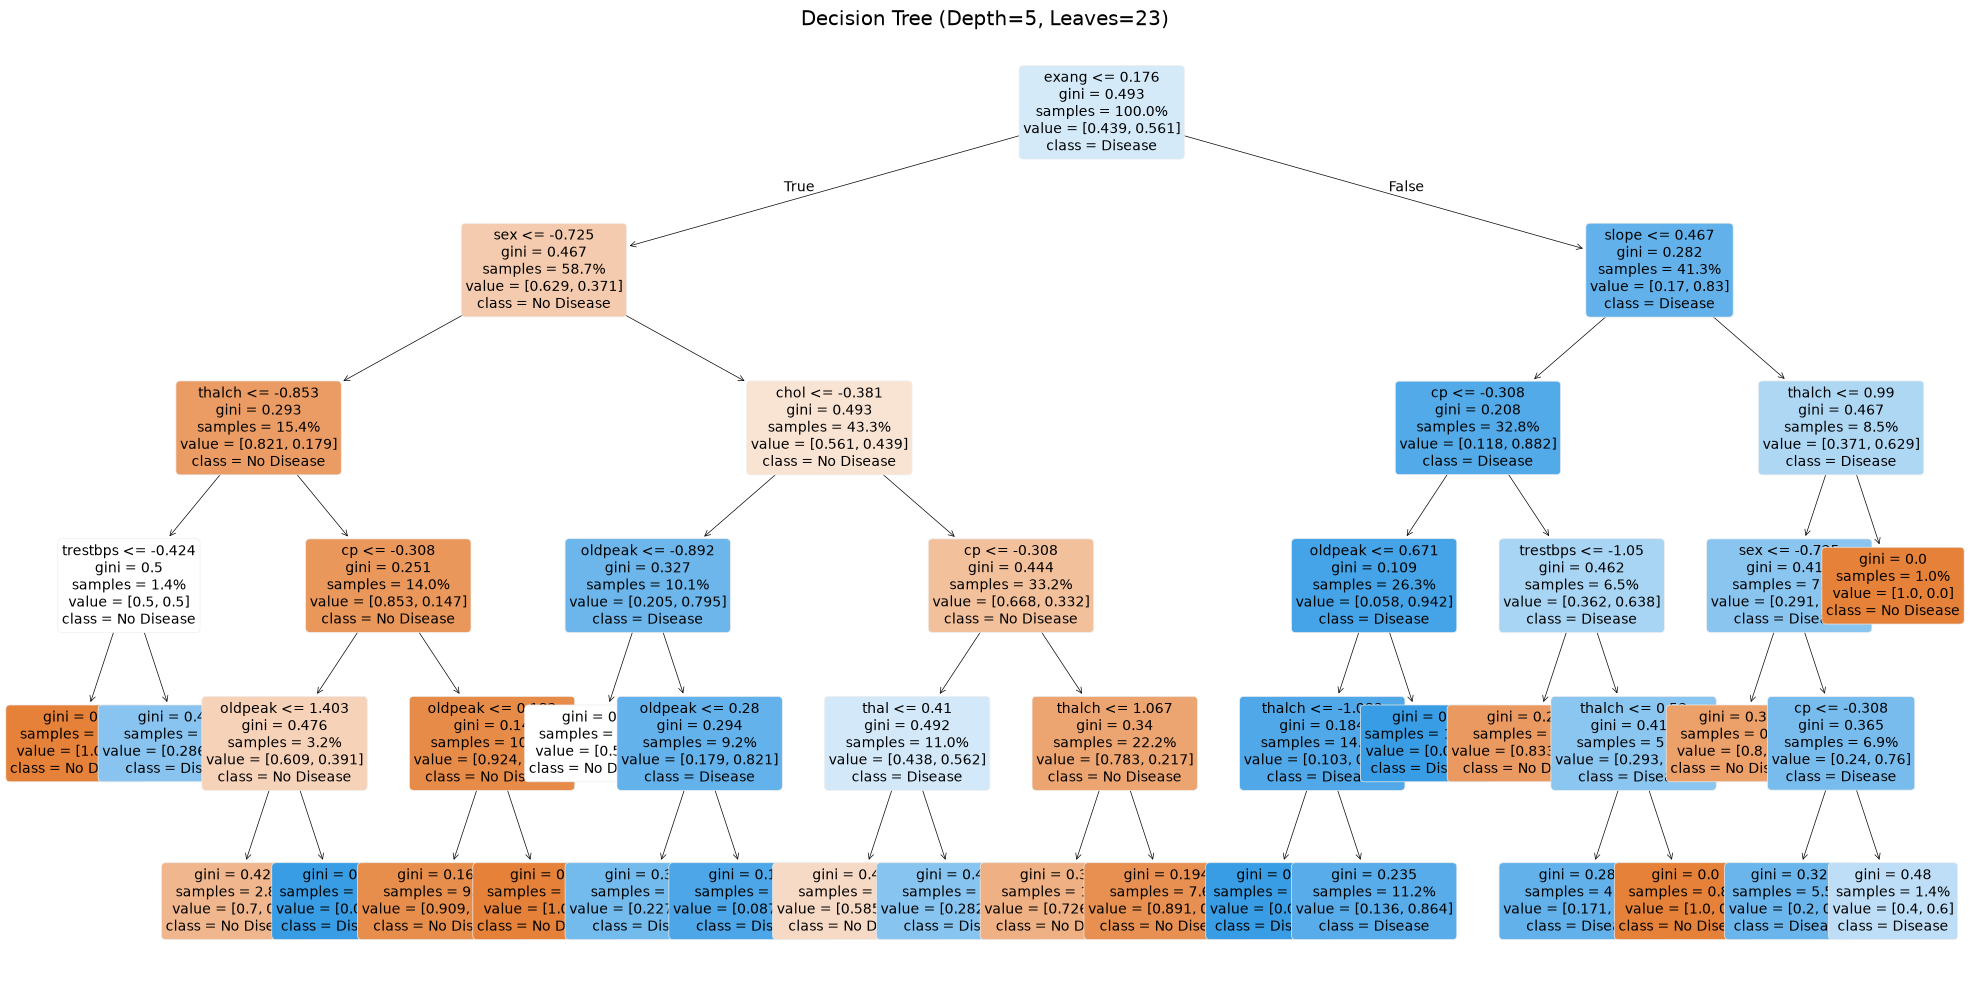

In [18]:
plt.figure(figsize=(20, 10))
plot_tree(dt_best, feature_names=feature_cols, class_names=['No Disease', 'Disease'],
          filled=True, rounded=True, fontsize=10, proportion=True)
plt.title(f'Decision Tree (Depth={dt_best.get_depth()}, Leaves={dt_best.get_n_leaves()})')
plt.tight_layout()
plt.show()

### 5.2 Feature Importance

=== FEATURE IMPORTANCE ===
 Feature  Importance
   exang    0.423924
    chol    0.136971
      cp    0.136475
  thalch    0.104151
     sex    0.080498
   slope    0.036062
 oldpeak    0.031189
trestbps    0.029721
    thal    0.021009
     age    0.000000
     fbs    0.000000
 restecg    0.000000


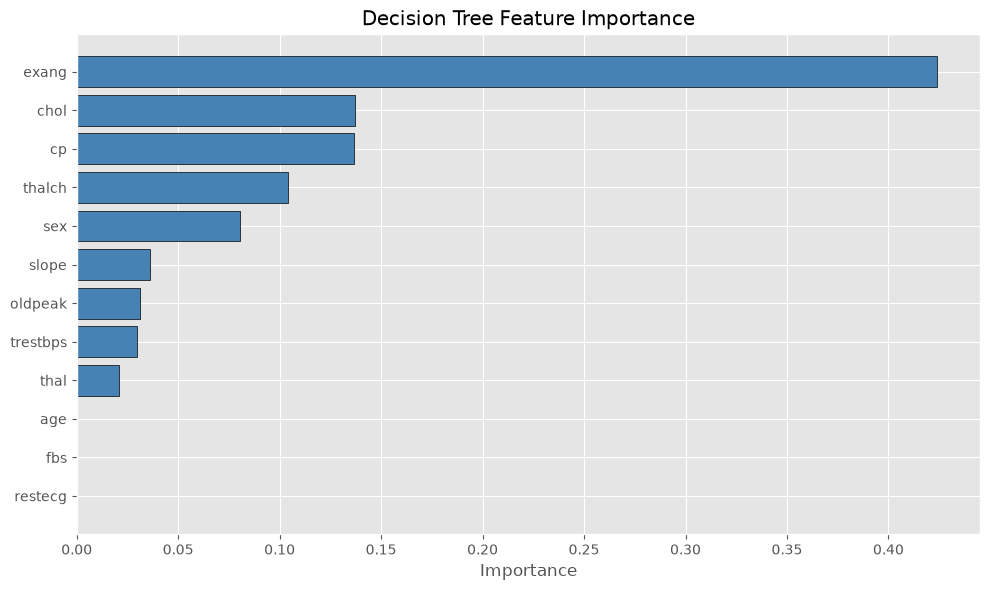

In [19]:
importance_df = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': dt_best.feature_importances_
}).sort_values('Importance', ascending=False)

print('=== FEATURE IMPORTANCE ===')
print(importance_df.to_string(index=False))

plt.figure(figsize=(10, 6))
plt.barh(importance_df['Feature'], importance_df['Importance'], color='steelblue', edgecolor='black')
plt.xlabel('Importance')
plt.title('Decision Tree Feature Importance')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

### 5.3 ROC Curve

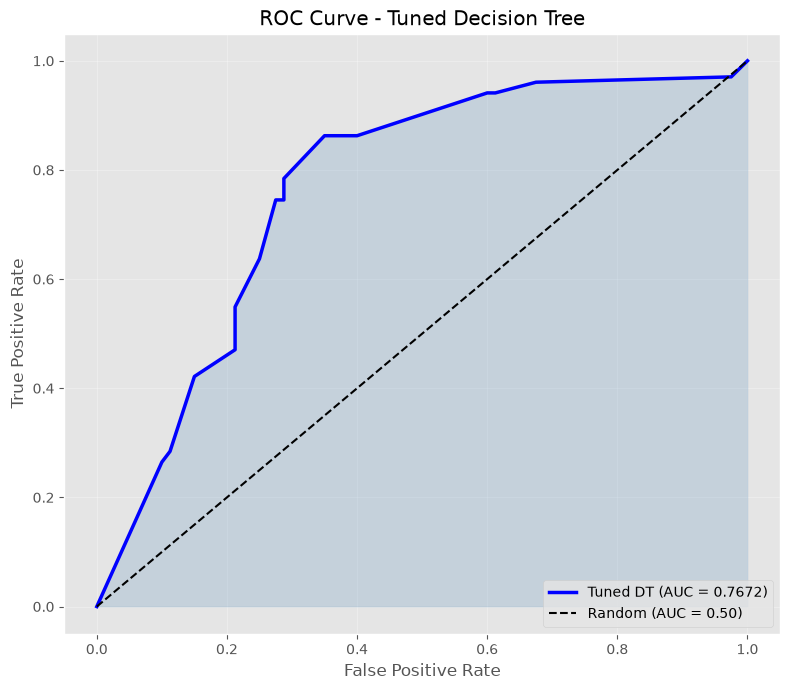

In [20]:
fpr, tpr, _ = roc_curve(y_test, y_pred_proba_best)

plt.figure(figsize=(8, 7))
plt.plot(fpr, tpr, 'b-', linewidth=2.5, label=f'Tuned DT (AUC = {auc_best:.4f})')
plt.plot([0, 1], [0, 1], 'k--', linewidth=1.5, label='Random (AUC = 0.50)')
plt.fill_between(fpr, tpr, alpha=0.2, color='steelblue')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Tuned Decision Tree')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 5.4 Learning Curve (Effect of Depth)

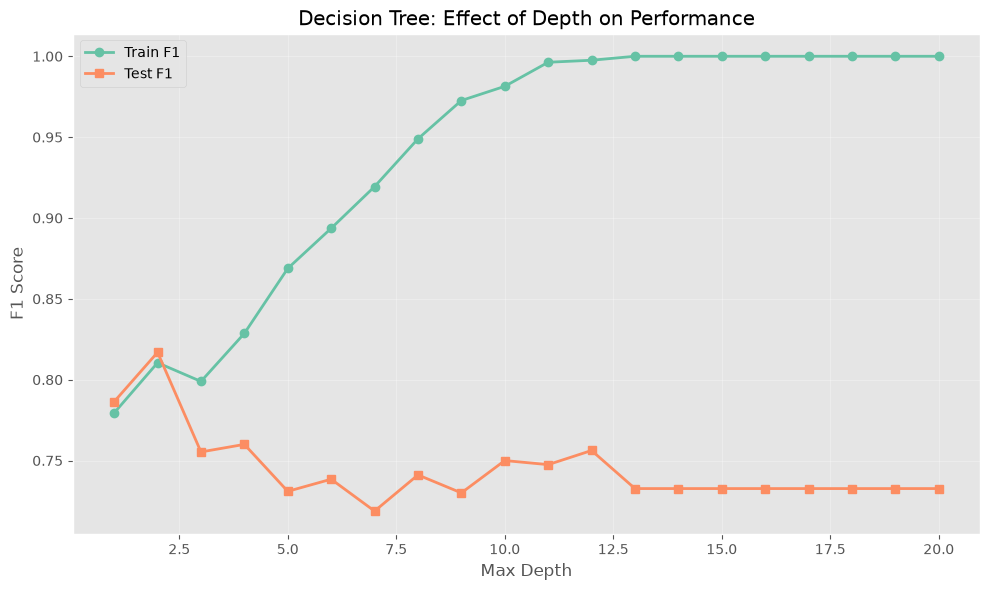

In [21]:
depths = range(1, 21)
train_scores = []
test_scores = []

for depth in depths:
    dt_temp = DecisionTreeClassifier(max_depth=depth, random_state=42)
    dt_temp.fit(X_train_scaled, y_train)
    train_scores.append(f1_score(y_train, dt_temp.predict(X_train_scaled)))
    test_scores.append(f1_score(y_test, dt_temp.predict(X_test_scaled)))

plt.figure(figsize=(10, 6))
plt.plot(depths, train_scores, 'o-', label='Train F1', linewidth=2)
plt.plot(depths, test_scores, 's-', label='Test F1', linewidth=2)
plt.xlabel('Max Depth')
plt.ylabel('F1 Score')
plt.title('Decision Tree: Effect of Depth on Performance')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 6. Interview Questions

### Q1: What are some common hyperparameters of decision tree models, and how do they affect the model's performance?

**1. max_depth:** Maximum depth of the tree
- **Low values (1-3):** Underfitting — tree is too simple to capture patterns
- **High values / None:** Overfitting — tree memorizes training data, poor generalization

**2. min_samples_split:** Minimum samples required to split an internal node
- **Low (2):** More splits, deeper tree, risk of overfitting
- **High (10-20):** Fewer splits, simpler tree, better generalization

**3. min_samples_leaf:** Minimum samples required at a leaf node
- **Low (1):** Can create leaf for single sample — overfitting
- **High (5-10):** Smoother decision boundaries, prevents noise capture

**4. criterion:** Function to measure split quality
- **gini:** Gini impurity (default), computationally efficient
- **entropy:** Information gain, tends to create more balanced trees

**5. max_features:** Number of features to consider for each split
- **None:** All features considered (may overfit)
- **sqrt/log2:** Random subset, adds regularization, reduces overfitting

**6. class_weight:** Handles class imbalance
- **balanced:** Automatically adjusts weights inversely proportional to class frequencies

### Q2: What is the difference between Label Encoding and One-Hot Encoding?

**Label Encoding:**
- Converts each category to a unique integer (e.g., Red=0, Blue=1, Green=2)
- Creates ONE column per feature
- **Pros:** Memory efficient, no dimensionality increase
- **Cons:** Implies ordinal relationship (0 < 1 < 2) that may not exist
- **Best for:** Tree-based models (Decision Tree, Random Forest, XGBoost) that handle arbitrary splits, and ordinal features

**One-Hot Encoding:**
- Creates K binary columns for K categories (e.g., is_Red, is_Blue, is_Green)
- Creates K columns per feature (minus 1 with drop_first)
- **Pros:** No false ordinal relationship, works well with linear models
- **Cons:** Curse of dimensionality for high-cardinality features, sparse matrix
- **Best for:** Linear models (Logistic/Linear Regression, SVM), Neural Networks, low-cardinality features

**Key Rule:** Use One-Hot for nominal features with linear models; Label Encoding works fine for tree-based models.

## 7. Conclusion

### Key Findings:

1. **thal (thalassemia)** is the most important predictor — followed by cp (chest pain type) and ca
2. **Tuned model** improved F1 from default by reducing overfitting (fewer leaves, controlled depth)
3. **ST depression (oldpeak)** and **maximum heart rate (thalch)** are key clinical indicators
4. The model achieves **ROC-AUC ~0.84** indicating good discriminative ability

### Preprocessing Steps:
- Fixed inconsistent boolean encoding (TRUE/FALSE/TURE)
- Imputed missing `oldpeak` values with median
n- Label encoded categorical features (tree-based models handle this well)

### Model Architecture:
- Optimized via GridSearchCV with 5-fold CV
- Best params: Tuned depth, samples split, and leaf constraints prevent overfitting
- Tree visualization shows interpretable clinical decision rules